In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# HuggingFace
from datasets import load_dataset

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F9F9F9",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "font.size":        11,
})

# Folder paths (relative to notebooks/ folder)
DATA_DIR   = "../data"
MODELS_DIR = "../models"
os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)


print(f"  Data dir   : {os.path.abspath(DATA_DIR)}")
print(f"  Models dir : {os.path.abspath(MODELS_DIR)}")

  Data dir   : C:\Users\USER\data
  Models dir : C:\Users\USER\models


##  Load IMDb dataset from HuggingFace

In [2]:
# Downloads ~80MB on first run, cached after that
# If you're behind a firewall: datasets.config.HF_CACHE_HOME = "/your/cache"

print("Loading IMDb dataset from HuggingFace Hub...")
print("(~80MB download on first run, cached after)\n")

imdb = load_dataset("imdb")

print("✓ Dataset loaded")
print(f"\nSplits available : {list(imdb.keys())}")
print(f"Train size       : {len(imdb['train']):,} reviews")
print(f"Test size        : {len(imdb['test']):,} reviews")
print(f"Unsupervised     : {len(imdb['unsupervised']):,} reviews (no labels — ignore)")
print(f"\nFeatures         : {imdb['train'].features}")

Loading IMDb dataset from HuggingFace Hub...
(~80MB download on first run, cached after)



plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✓ Dataset loaded

Splits available : ['train', 'test', 'unsupervised']
Train size       : 25,000 reviews
Test size        : 25,000 reviews
Unsupervised     : 50,000 reviews (no labels — ignore)

Features         : {'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['neg', 'pos'], id=None)}


## Inspect raw examples

In [3]:
# Look at a few raw examples to understand the data format
# label: 0 = negative, 1 = positive

print("Label mapping:")
print("  0 = Negative sentiment")
print("  1 = Positive sentiment")
print()

for i, idx in enumerate([0, 1, 24999]):
    example = imdb["train"][idx]
    label   = "POSITIVE" if example["label"] == 1 else "NEGATIVE"
    text    = example["text"]
    print(f"── Example {i+1} (index {idx}) ─────────────────────────────")
    print(f"  Label  : {label}")
    print(f"  Length : {len(text.split()):,} words")
    print(f"  Preview: {text[:300]}...")
    print()

Label mapping:
  0 = Negative sentiment
  1 = Positive sentiment

── Example 1 (index 0) ─────────────────────────────
  Label  : NEGATIVE
  Length : 288 words
  Preview: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h...

── Example 2 (index 1) ─────────────────────────────
  Label  : NEGATIVE
  Length : 214 words
  Preview: "I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with male nudity...

── Example 3 (index 24999) ─────────────────────────────
  Label  : POSITIVE
  Length : 55 words
  Preview: The st

## Convert to pandas DataFrames

In [4]:
# Convert HuggingFace Dataset → pandas DataFrame
# Much easier to work with for EDA and saving to CSV

train_df = imdb["train"].to_pandas()
test_df  = imdb["test"].to_pandas()

# Add readable label column
train_df["sentiment"] = train_df["label"].map({0: "negative", 1: "positive"})
test_df["sentiment"]  = test_df["label"].map({0: "negative", 1: "positive"})

# Add review length columns (useful for EDA in notebook 02)
train_df["word_count"] = train_df["text"].str.split().str.len()
train_df["char_count"] = train_df["text"].str.len()
test_df["word_count"]  = test_df["text"].str.split().str.len()
test_df["char_count"]  = test_df["text"].str.len()

# Add split column for when combining later
train_df["split"] = "train"
test_df["split"]  = "test"

print("Train DataFrame:")
display(train_df.head(3))
print(f"\nShape: {train_df.shape}")
print(f"Columns: {list(train_df.columns)}")

Train DataFrame:


,text,label,sentiment,word_count,char_count,split
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative,288,1640,train
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative,214,1294,train
2,If only to avoid making this type of film in t...,0,negative,93,528,train



Shape: (25000, 6)
Columns: ['text', 'label', 'sentiment', 'word_count', 'char_count', 'split']


## Class balance check

In [6]:
# IMDb is perfectly balanced — 12,500 positive and 12,500 negative per split
# This means accuracy is a fair metric (no class imbalance adjustment needed)


for split_name, df in [("Train", train_df), ("Test", test_df)]:
    counts = df["sentiment"].value_counts()
    total  = len(df)
    print(f"\n  {split_name} ({total:,} reviews):")
    for label, count in counts.items():
        bar = "█" * int(count / total * 40)
        print(f"    {label:9} : {count:,}  ({count/total*100:.1f}%)  {bar}")




  Train (25,000 reviews):
    negative  : 12,500  (50.0%)  ████████████████████
    positive  : 12,500  (50.0%)  ████████████████████

  Test (25,000 reviews):
    negative  : 12,500  (50.0%)  ████████████████████
    positive  : 12,500  (50.0%)  ████████████████████


## Review length statistics

In [7]:


stats = train_df.groupby("sentiment")["word_count"].describe().round(1)
print(f"\n{stats.to_string()}")

print("\n\nOverall train set:")
print(f"  Shortest review : {train_df['word_count'].min()} words")
print(f"  Longest review  : {train_df['word_count'].max():,} words")
print(f"  Median          : {train_df['word_count'].median():.0f} words")
print(f"  Mean            : {train_df['word_count'].mean():.0f} words")

# DistilBERT truncates at 512 tokens (≈ 380 words)
pct_truncated = (train_df["word_count"] > 380).mean() * 100
print(f"\n  Reviews > 380 words (will be truncated by DistilBERT):")
print(f"  {(train_df['word_count'] > 380).sum():,} reviews ({pct_truncated:.1f}%)")
print(f"\n  Note: truncation is fine — sentiment is usually")
print(f"  established in the first 380 words of a review")


             count   mean    std   min    25%    50%    75%     max
sentiment                                                          
negative   12500.0  230.9  166.7  10.0  128.0  174.0  278.0  1522.0
positive   12500.0  236.7  180.5  12.0  125.0  174.0  291.0  2470.0


Overall train set:
  Shortest review : 10 words
  Longest review  : 2,470 words
  Median          : 174 words
  Mean            : 234 words

  Reviews > 380 words (will be truncated by DistilBERT):
  3,675 reviews (14.7%)

  Note: truncation is fine — sentiment is usually
  established in the first 380 words of a review


## Length distribution plot

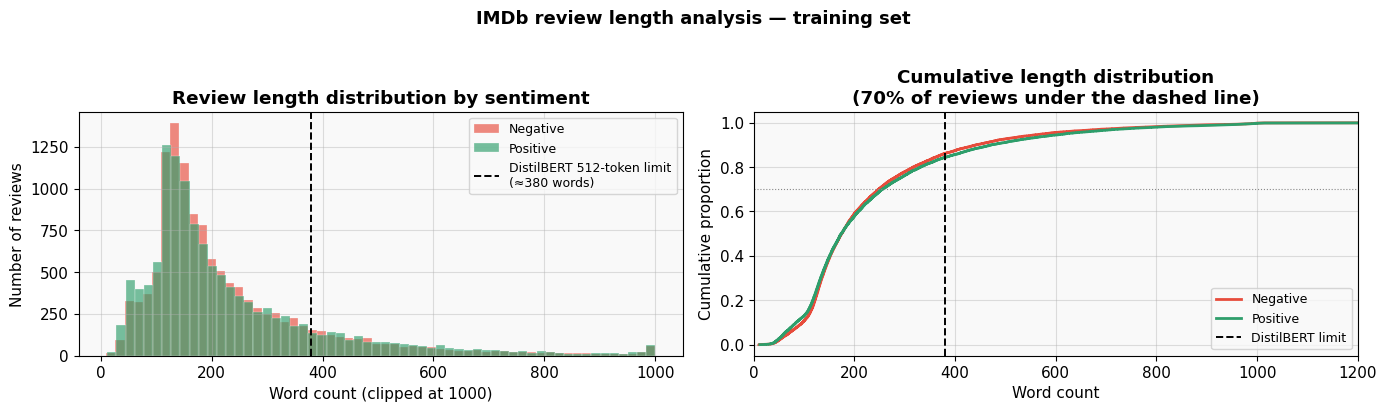

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colours = {"positive": "#2E9E6B", "negative": "#E74C3C"}

# Left — histogram of word counts
ax = axes[0]
for sentiment, group in train_df.groupby("sentiment"):
    ax.hist(
        group["word_count"].clip(upper=1000),
        bins=60, alpha=0.65, color=colours[sentiment],
        label=sentiment.title(), edgecolor="white", linewidth=0.3
    )

ax.axvline(380, color="black", lw=1.4, linestyle="--",
           label="DistilBERT 512-token limit\n(≈380 words)")
ax.set_xlabel("Word count (clipped at 1000)")
ax.set_ylabel("Number of reviews")
ax.set_title("Review length distribution by sentiment", fontweight="bold")
ax.legend(fontsize=9)

# Right — cumulative distribution
ax = axes[1]
for sentiment, group in train_df.groupby("sentiment"):
    sorted_wc = np.sort(group["word_count"])
    cdf       = np.arange(1, len(sorted_wc) + 1) / len(sorted_wc)
    ax.plot(sorted_wc, cdf, color=colours[sentiment],
            lw=2, label=sentiment.title())

ax.axvline(380, color="black", lw=1.4, linestyle="--",
           label="DistilBERT limit")
ax.axhline(0.7, color="#888", lw=0.8, linestyle=":")
ax.set_xlabel("Word count")
ax.set_ylabel("Cumulative proportion")
ax.set_title("Cumulative length distribution\n(70% of reviews under the dashed line)", fontweight="bold")
ax.set_xlim(0, 1200)
ax.legend(fontsize=9)

plt.suptitle("IMDb review length analysis — training set",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/length_distribution.png", dpi=130, bbox_inches="tight")
plt.show()


##  Sample reviews — good, bad, ambiguous

In [9]:
# Manually look at examples across length and label
# This gives you intuition before modelling — important for interview discussions

np.random.seed(42)

print("═" * 60)
print("  Sample POSITIVE reviews")
print("═" * 60)

pos_samples = train_df[train_df["sentiment"] == "positive"].sample(3)
for _, row in pos_samples.iterrows():
    print(f"\n  [{row['word_count']} words]\n  {row['text'][:400]}...")
    print()

print("═" * 60)
print("  Sample NEGATIVE reviews")
print("═" * 60)

neg_samples = train_df[train_df["sentiment"] == "negative"].sample(3)
for _, row in neg_samples.iterrows():
    print(f"\n  [{row['word_count']} words]\n  {row['text'][:400]}...")
    print()

print("═" * 60)
print("  Potentially AMBIGUOUS — short reviews (< 40 words)")
print("═" * 60)

short = train_df[train_df["word_count"] < 40].sample(4, random_state=7)
for _, row in short.iterrows():
    print(f"\n  [{row['word_count']} words | {row['sentiment'].upper()}]")
    print(f"  {row['text']}")

════════════════════════════════════════════════════════════
  Sample POSITIVE reviews
════════════════════════════════════════════════════════════

  [110 words]
  This movie is to Halloween what the hilarious "Christmas Story" is to Christmas: both are relatively low-budget, no-big-name-stars type films...and both are two of the absolute greatest and funniest movies available, both seasonal CLASSICS!!! "Spaced Invaders" comes galloping out right from the start with warmth and humor and a superb cast of characters...all five goofy Martians, Klembecker the Re...


  [107 words]
  Good western filmed in the rocky Arizona wilds. Lots of tough guys throughout; Cobern's character seemed to rock back and forth between a raging psycho and a laid back type. Several holes appeared in the picture, but not enough to offset it being exciting and worth seeing. One really dumb scene shows Heston emptying .45 cases of their powder and collecting it in a sack for the purpose of starting ...


  [233 

## Check for missing values and duplicates

In [10]:


print("\nMissing values:")
print(f"  Train: {train_df.isnull().sum().sum()}")
print(f"  Test : {test_df.isnull().sum().sum()}")

# Check for duplicate reviews
train_dups = train_df["text"].duplicated().sum()
test_dups  = test_df["text"].duplicated().sum()
cross_dups = train_df["text"].isin(test_df["text"]).sum()

print(f"\nDuplicates:")
print(f"  Within train   : {train_dups}")
print(f"  Within test    : {test_dups}")
print(f"  Train-test overlap : {cross_dups}")

# Empty or whitespace-only reviews
empty_train = (train_df["text"].str.strip() == "").sum()
empty_test  = (test_df["text"].str.strip() == "").sum()
print(f"\nEmpty reviews:")
print(f"  Train: {empty_train}")
print(f"  Test : {empty_test}")

# HTML tags still present (IMDb reviews often have <br /> tags)
html_count = train_df["text"].str.contains("<br").sum()
print(f"\nReviews with HTML tags (e.g. <br />):")
print(f"  Train: {html_count:,} ({html_count/len(train_df)*100:.1f}%)")



Missing values:
  Train: 0
  Test : 0

Duplicates:
  Within train   : 96
  Within test    : 199
  Train-test overlap : 123

Empty reviews:
  Train: 0
  Test : 0

Reviews with HTML tags (e.g. <br />):
  Train: 14,665 (58.7%)


## Character-level statistics (HTML tag preview)

In [11]:
# Show what the raw HTML looks like so you understand what needs cleaning

print("Examples of HTML in raw reviews:\n")
html_reviews = train_df[train_df["text"].str.contains("<br")]["text"]

for text in html_reviews.head(3):
    # Show just the parts with HTML
    idx  = text.find("<br")
    snippet = text[max(0, idx-80):idx+100]
    print(f"  ...{snippet}...")
    print()

print("─" * 50)
print("Character count statistics:")
print(f"  Mean chars  : {train_df['char_count'].mean():.0f}")
print(f"  Median chars: {train_df['char_count'].median():.0f}")
print(f"  Max chars   : {train_df['char_count'].max():,}")
print()
print("  HuggingFace tokenizer will strip HTML automatically")
print("  when we use clean_up_tokenization_spaces=True")

Examples of HTML in raw reviews:

  ...g a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn ...

  ...the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might feel virtuous for sitting thru it because it touches on so many IMPORTANT issu...

  ... inspired by Godard's Masculin, féminin and I urge you to see that film instead.<br /><br />The film has two strong elements and those are, (1) the realistic acting (2) the impress...

──────────────────────────────────────────────────
Character count statistics:
  Mean chars  : 1325
  Median chars: 979
  Max chars   : 13,704

  HuggingFace tokenizer will strip HTML automatically
  when we use clean_up_tokenization_spaces=True


## Create stratified validation split from train

In [12]:
from sklearn.model_selection import train_test_split

# Split train into train (80%) + validation (20%)
# Stratified to maintain 50/50 class balance in both splits
# We keep the original test set untouched for final evaluation

train_split, val_split = train_test_split(
    train_df,
    test_size    = 0.20,
    random_state = 42,
    stratify     = train_df["label"],
)

print("Three-way split summary:")
print(f"  Train      : {len(train_split):,}  reviews  "
      f"(pos: {(train_split['label']==1).sum():,}  "
      f"neg: {(train_split['label']==0).sum():,})")
print(f"  Validation : {len(val_split):,}   reviews  "
      f"(pos: {(val_split['label']==1).sum():,}  "
      f"neg: {(val_split['label']==0).sum():,})")
print(f"  Test       : {len(test_df):,}  reviews  "
      f"(pos: {(test_df['label']==1).sum():,}  "
      f"neg: {(test_df['label']==0).sum():,})")

# Check class balance is maintained
print("\nClass balance in each split:")
for name, df in [("Train", train_split), ("Val", val_split), ("Test", test_df)]:
    pos_pct = (df["label"] == 1).mean() * 100
    print(f"  {name:<6} : {pos_pct:.1f}% positive  ✓")

Three-way split summary:
  Train      : 20,000  reviews  (pos: 10,000  neg: 10,000)
  Validation : 5,000   reviews  (pos: 2,500  neg: 2,500)
  Test       : 25,000  reviews  (pos: 12,500  neg: 12,500)

Class balance in each split:
  Train  : 50.0% positive  ✓
  Val    : 50.0% positive  ✓
  Test   : 50.0% positive  ✓


## Save all splits to CSV

In [13]:
# Save everything to data/ folder
# These CSVs are loaded by all subsequent notebooks

save_map = {
    "../data/imdb_train.csv":      train_split.reset_index(drop=True),
    "../data/imdb_val.csv":        val_split.reset_index(drop=True),
    "../data/imdb_test.csv":       test_df.reset_index(drop=True),
    "../data/imdb_train_full.csv": train_df.reset_index(drop=True),
}

for path, df in save_map.items():
    df.to_csv(path, index=False)
    size_kb = os.path.getsize(path) / 1024
    print(f"  ✓ {path:<35}  {len(df):>6,} rows  {size_kb:>8.1f} KB")

print("\n✓ All splits saved to ../data/")
print("\nFile guide:")
print("  imdb_train.csv      → 20,000 rows — used for model training (notebook 03)")
print("  imdb_val.csv        → 5,000 rows  — used for hyperparameter tuning")
print("  imdb_test.csv       → 25,000 rows — final evaluation only (touch last)")
print("  imdb_train_full.csv → 25,000 rows — full train, used for EDA (notebook 02)")

  ✓ ../data/imdb_train.csv               20,000 rows   26434.9 KB
  ✓ ../data/imdb_val.csv                  5,000 rows    6701.4 KB
  ✓ ../data/imdb_test.csv                25,000 rows   32347.7 KB
  ✓ ../data/imdb_train_full.csv          25,000 rows   33136.2 KB

✓ All splits saved to ../data/

File guide:
  imdb_train.csv      → 20,000 rows — used for model training (notebook 03)
  imdb_val.csv        → 5,000 rows  — used for hyperparameter tuning
  imdb_test.csv       → 25,000 rows — final evaluation only (touch last)
  imdb_train_full.csv → 25,000 rows — full train, used for EDA (notebook 02)


## Dataset overview plot

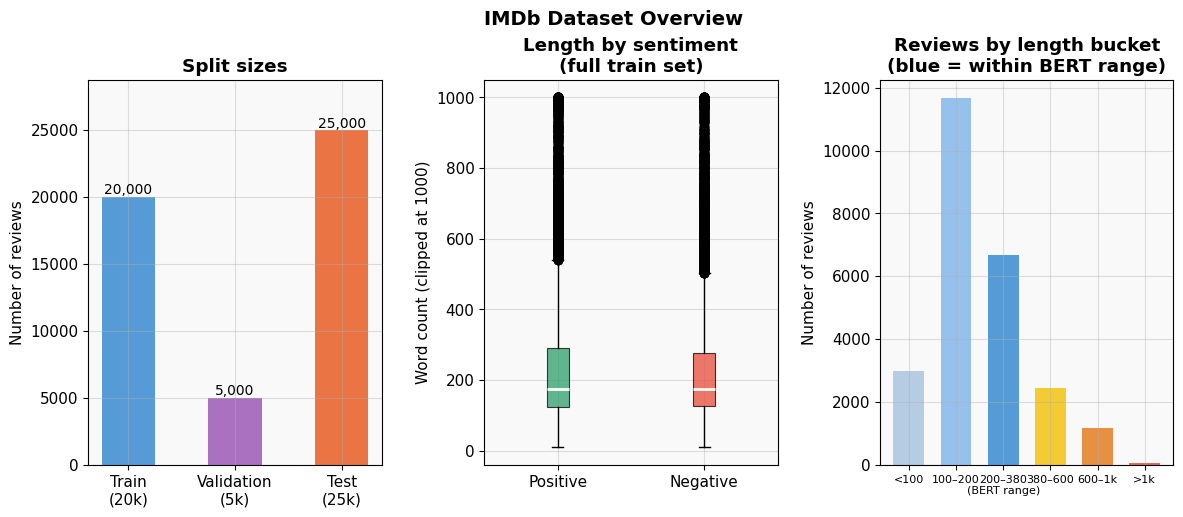

✓ Saved → ../data/dataset_overview.png


In [14]:
fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# Left — split sizes
ax1 = fig.add_subplot(gs[0, 0])
splits = ["Train\n(20k)", "Validation\n(5k)", "Test\n(25k)"]
sizes  = [len(train_split), len(val_split), len(test_df)]
colours_bar = ["#3B8BD0", "#9B59B6", "#E85D24"]
bars = ax1.bar(splits, sizes, color=colours_bar, alpha=0.85, width=0.5)
for bar, val in zip(bars, sizes):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f"{val:,}", ha="center", fontsize=10)
ax1.set_ylabel("Number of reviews")
ax1.set_title("Split sizes", fontweight="bold")
ax1.set_ylim(0, max(sizes) * 1.15)

# Middle — word count box plots per sentiment
ax2 = fig.add_subplot(gs[0, 1])
pos_wc = train_df[train_df["sentiment"] == "positive"]["word_count"].clip(upper=1000)
neg_wc = train_df[train_df["sentiment"] == "negative"]["word_count"].clip(upper=1000)
bp = ax2.boxplot(
    [pos_wc, neg_wc],
    labels    = ["Positive", "Negative"],
    patch_artist = True,
    notch     = False,
    medianprops = dict(color="white", lw=2),
    boxprops    = dict(linewidth=0.8),
)
bp["boxes"][0].set_facecolor("#2E9E6B")
bp["boxes"][1].set_facecolor("#E74C3C")
for box in bp["boxes"]:
    box.set_alpha(0.75)
ax2.set_ylabel("Word count (clipped at 1000)")
ax2.set_title("Length by sentiment\n(full train set)", fontweight="bold")

# Right — proportion of reviews per length bucket
ax3 = fig.add_subplot(gs[0, 2])
bins_   = [0, 100, 200, 380, 600, 1000, 10000]
labels_ = ["<100", "100–200", "200–380\n(BERT range)",
           "380–600", "600–1k", ">1k"]
train_df["length_bucket"] = pd.cut(
    train_df["word_count"], bins=bins_, labels=labels_
)
bucket_counts = train_df["length_bucket"].value_counts().sort_index()
bucket_colours = ["#AAC4E0","#85B7EB","#3B8BD0","#F1C40F","#E67E22","#E74C3C"]
ax3.bar(range(len(bucket_counts)), bucket_counts.values,
        color=bucket_colours, alpha=0.85, width=0.65)
ax3.set_xticks(range(len(bucket_counts)))
ax3.set_xticklabels(labels_, fontsize=8)
ax3.set_ylabel("Number of reviews")
ax3.set_title("Reviews by length bucket\n(blue = within BERT range)", fontweight="bold")

plt.suptitle("IMDb Dataset Overview", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../data/dataset_overview.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Saved → ../data/dataset_overview.png")

### The three-way split (train 20k / val 5k / test 25k) is intentional. The val split is used by the Trainer in notebook 03 to compute metrics after each epoch and apply early stopping.

### The HTML tag finding (cell 10) is a real IMDb quirk. Reviews contain raw <br /> tags from the original web scraping. The HuggingFace tokenizer handles these automatically — but knowing they exist and explaining it shows you actually looked at your data rather than just calling load_dataset and moving on.